In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")       # preferred Seaborn style
sns.set_palette("husl")  

# Load data
app = pd.read_csv(r'../data\raw\application_train.csv')
print(f'Shape: {app.shape}')
print(f'Default Rate: {app["TARGET"].mean():.2%}')
app.head()


Shape: (307511, 122)
Default Rate: 8.07%


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None
          SK_ID_CURR         TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL  \
count  307511.000000  307511.000000  307511.000000      3.075110e+05   
mean   278180.518577       0.080729       0.417052      1.687979e+05   
std    102790.175348       0.272419       0.722121      2.371231e+05   
min    100002.000000       0.000000       0.000000      2.565000e+04   
25%    189145.500000       0.000000       0.000000      1.125000e+05   
50%    278202.000000       0.000000       0.000000      1.471500e+05   
75%    367142.500000       0.000000       1.000000      2.025000e+05   
max    456255.000000       1.000000      19.000000      1.170000e+08   

         AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  \
count  3.075110e+05  307499.000000     3.072330e+05   
mean   5.990260e+05   27108.

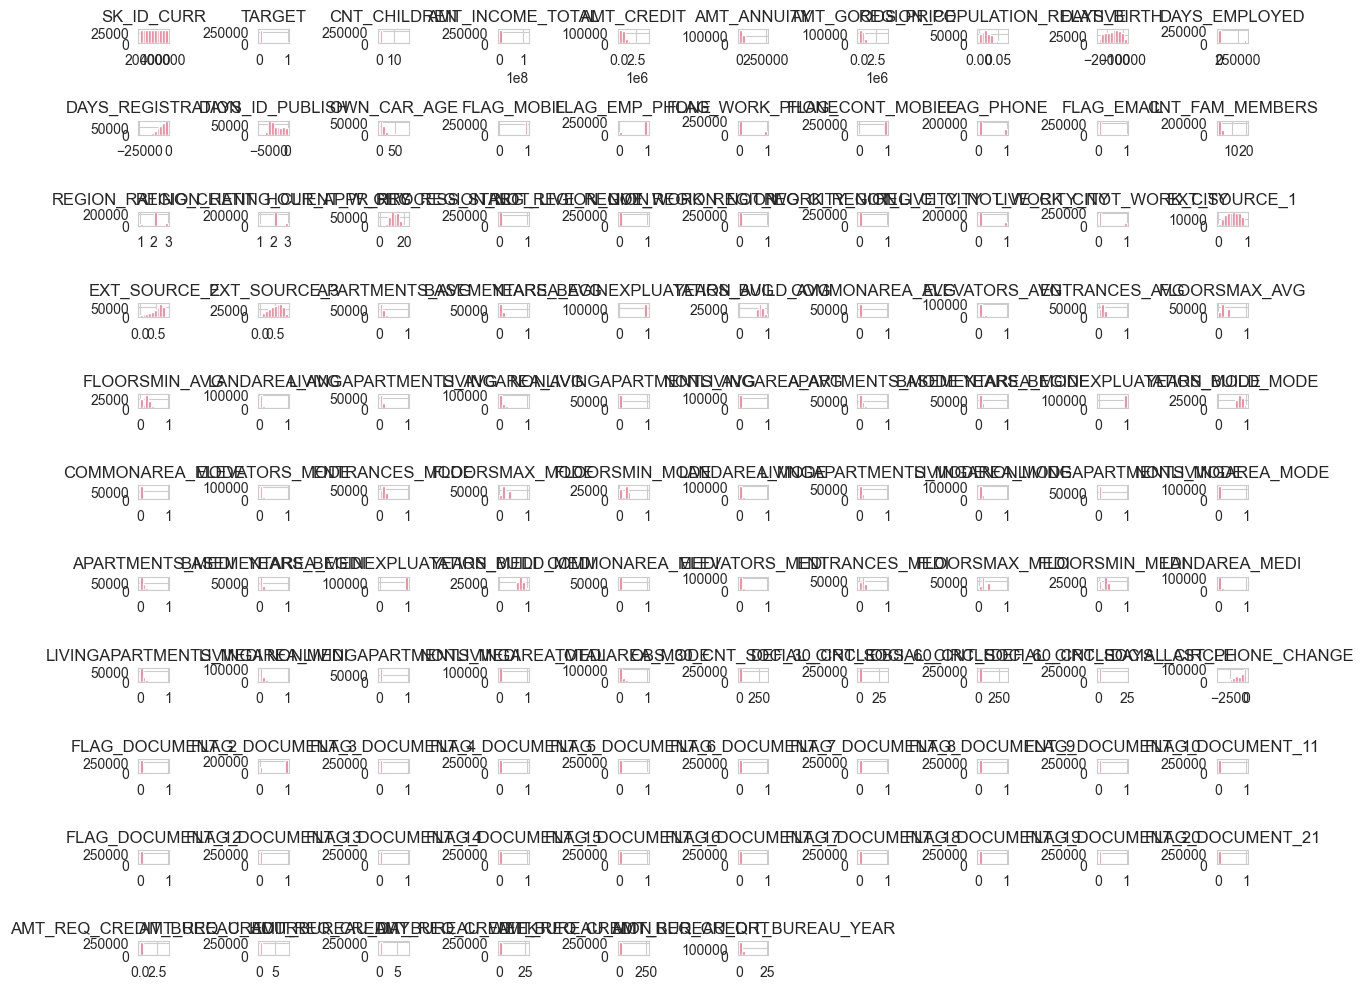

   SK_ID_CURR  TARGET  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  \
0      100002       1             0          202500.0    406597.5   
1      100003       0             0          270000.0   1293502.5   
2      100004       0             0           67500.0    135000.0   
3      100006       0             0          135000.0    312682.5   
4      100007       0             0          121500.0    513000.0   

   AMT_ANNUITY  AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  \
0      24700.5         351000.0                    0.018801       -9461   
1      35698.5        1129500.0                    0.003541      -16765   
2       6750.0         135000.0                    0.010032      -19046   
3      29686.5         297000.0                    0.008019      -19005   
4      21865.5         513000.0                    0.028663      -19932   

   DAYS_EMPLOYED  ...  FLAG_DOCUMENT_18  FLAG_DOCUMENT_19  FLAG_DOCUMENT_20  \
0           -637  ...                 0                

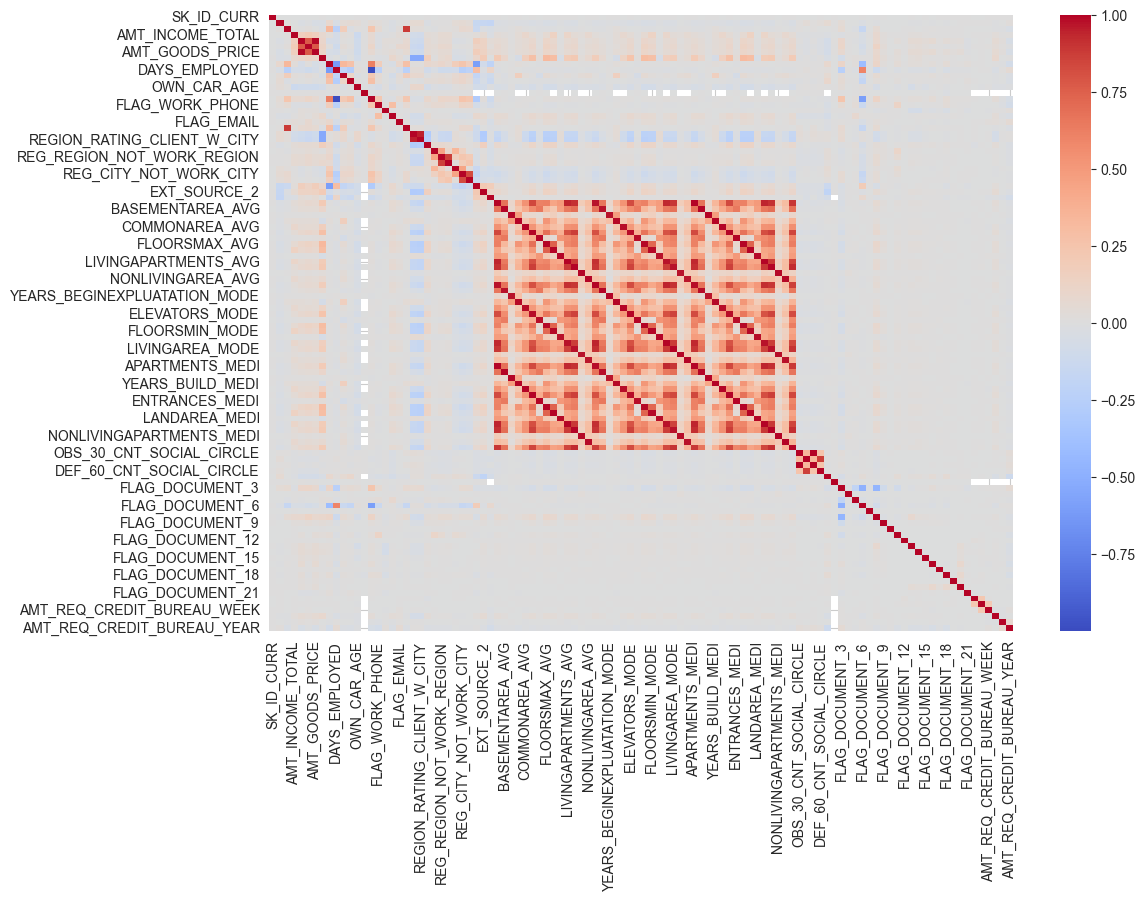

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
app = pd.read_csv('../data/raw/application_train.csv')

# Basic info
print(app.info())
print(app.describe())
print(app['TARGET'].value_counts(normalize=True))  # default rate

# Histograms
app.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

numeric_cols = app.select_dtypes(include=['int64', 'float64'])
print(numeric_cols.head())

# Correlation heatmap


plt.figure(figsize=(12, 8))
sns.heatmap(numeric_cols.corr(), cmap='coolwarm', annot=False)
plt.show()


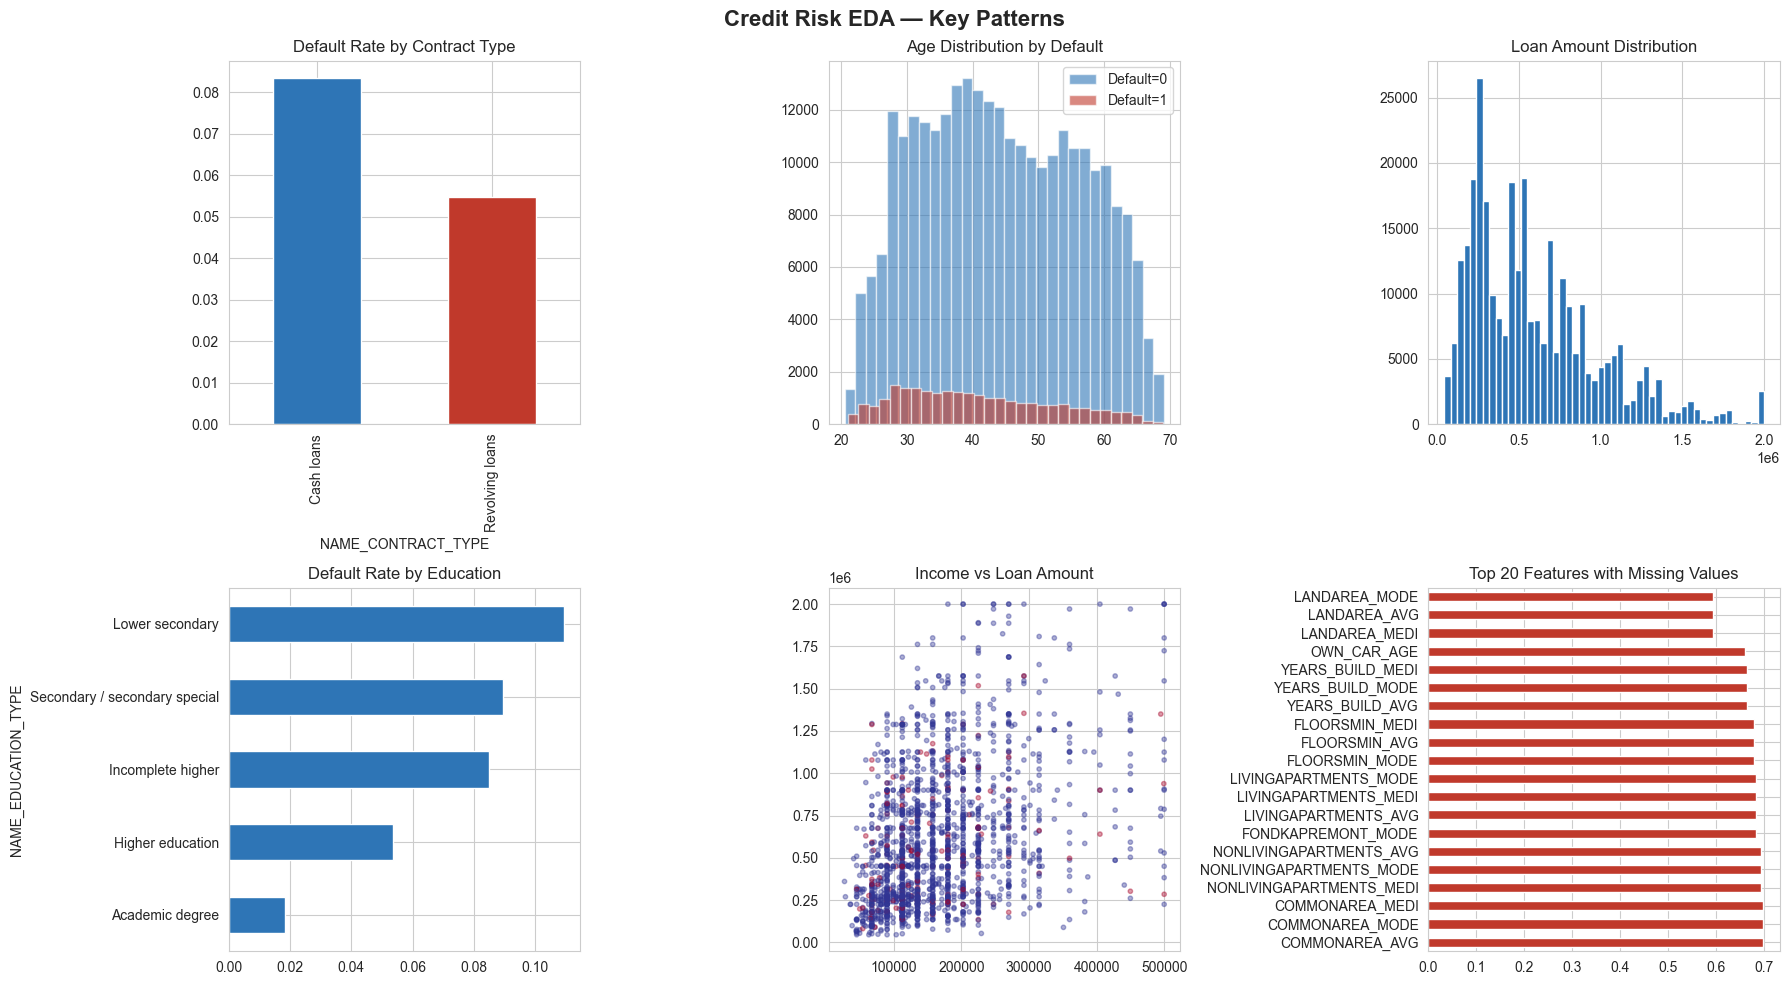

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Credit Risk EDA — Key Patterns', fontsize=16, fontweight='bold')

# 1. Default rate by contract type
app.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean().plot(
    kind='bar', ax=axes[0,0], title='Default Rate by Contract Type',
    color=['#2E75B6','#C0392B'])

# 2. Age distribution by default
for target, color in [(0,'#2E75B6'),(1,'#C0392B')]:
    subset = app[app['TARGET']==target]
    axes[0,1].hist(-subset['DAYS_BIRTH']/365, bins=30, alpha=0.6,
                   label=f'Default={target}', color=color)
axes[0,1].set_title('Age Distribution by Default')
axes[0,1].legend()

# 3. Credit amount distribution
app['AMT_CREDIT'].clip(upper=2e6).hist(
    bins=50, ax=axes[0,2], color='#2E75B6')
axes[0,2].set_title('Loan Amount Distribution')

# 4. Default rate by education
app.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values().plot(
    kind='barh', ax=axes[1,0], title='Default Rate by Education', color='#2E75B6')

# 5. Income vs Credit (scatter sample)
sample = app.sample(2000, random_state=42)
axes[1,1].scatter(
    sample['AMT_INCOME_TOTAL'].clip(upper=500000),
    sample['AMT_CREDIT'].clip(upper=2e6),
    c=sample['TARGET'], cmap='RdYlBu_r', alpha=0.4, s=10)
axes[1,1].set_title('Income vs Loan Amount')

# 6. Missing values top 20
missing = app.isnull().mean().sort_values(ascending=False).head(20)
missing.plot(kind='barh', ax=axes[1,2], color='#C0392B',
             title='Top 20 Features with Missing Values')

plt.tight_layout()
plt.savefig('../reports/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Default rate breakdown table
summary = pd.DataFrame({
    'Total Applications': [len(app)],
    'Default Rate': [f"{app['TARGET'].mean():.2%}"],
    'Avg Loan Amount': [f"${app['AMT_CREDIT'].mean():,.0f}"],
    'Avg Income': [f"${app['AMT_INCOME_TOTAL'].mean():,.0f}"],
    'Missing Values %': [f"{app.isnull().mean().mean():.1%}"],
    'Duplicate Rows': [app.duplicated().sum()]
})
summary.T.rename(columns={0:'Value'})


,Value
Total Applications,307511
Default Rate,8.07%
Avg Loan Amount,"$599,026"
Avg Income,"$168,798"
Missing Values %,24.4%
Duplicate Rows,0
